In [1]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [2]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [3]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output, plot_ldos
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\min

In [4]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'Gamma'
quantum_band_interactions = r'Gamma_Gamma'

C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\manual_build_array_x(15)\bias_00000\OpticsQuantum\quantum_region


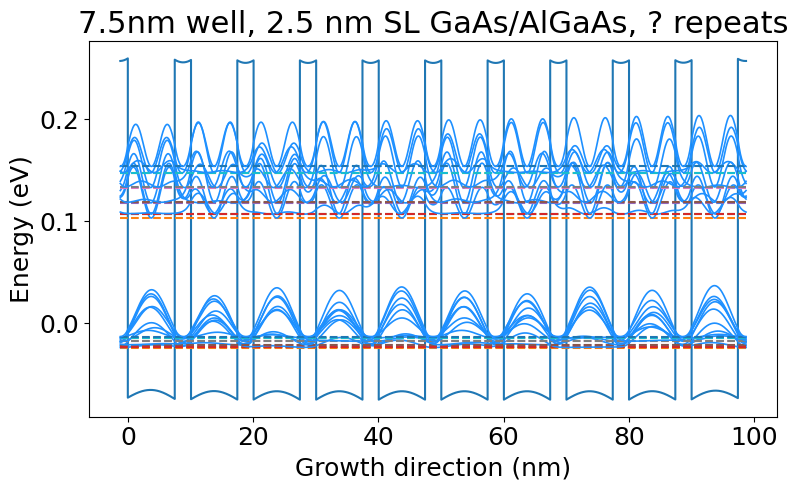


Intersubband transition energies — CB
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
  4 →  5 | -0.0001
  2 →  3 | -0.0001
  6 →  7 | -0.0001
  8 →  9 | -0.0002
 18 → 19 | -0.0004
 12 → 13 | -0.0005
 16 → 17 | -0.0006
 14 → 15 | -0.0006
  1 →  2 | -0.0009
  1 →  3 | -0.0010
  9 → 10 | -0.0013
  8 → 10 | -0.0015
  3 →  4 | -0.0025
  3 →  5 | -0.0026
  2 →  4 | -0.0026
  2 →  5 | -0.0027
  7 →  8 | -0.0030
  6 →  8 | -0.0031
  7 →  9 | -0.0032
  6 →  9 | -0.0033
  5 →  6 | -0.0034
  4 →  6 | -0.0035
  1 →  4 | -0.0035
  5 →  7 | -0.0035
  1 →  5 | -0.0036
  4 →  7 | -0.0036
 11 → 12 | -0.0038
 11 → 13 | -0.0043
  7 → 10 | -0.0045
  6 → 10 | -0.0046
  3 →  6 | -0.0060
 19 → 20 | -0.0061
  2 →  6 | -0.0061
  3 →  7 | -0.0061
  2 →  7 | -0.0062
 18 → 20 | -0.0064
  5 →  8 | -0.0066
  4 →  8 | -0.0066
  5 →  9 | -0.0068
  4 →  9 | -0.0068
  1 →  6 | -0.0070
  1 →  7 | -0.0071
  5 → 10 | -0.0080
  4 → 10 | -0.0081


In [5]:
# %matplotlib widget
parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\manual_build_array_x(15)"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1Dsuperlattice_5nm_well_Nsweep_nnp(4)"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\confirming_dipole_matrix_elements_expected(6)"

VB_cutoff = -1.0
simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,VB_cutoff,14,model='gamma')
simoutidk.bands['CB'].sort_subbands(decreasing=False)

simoutidk.bands['CB'].plot_band(title_diff='7.5nm well, 2.5 nm SL GaAs/AlGaAs, ? repeats',show_legend=False)
# simoutidk.bands['CB'].plot_band(title_diff='10nm SW GaAs/AlGaAs',normalize_y=False,show_legend=True)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")


Text(0, 0.5, '$V_{bias}$ with respect to $E_{F}$')

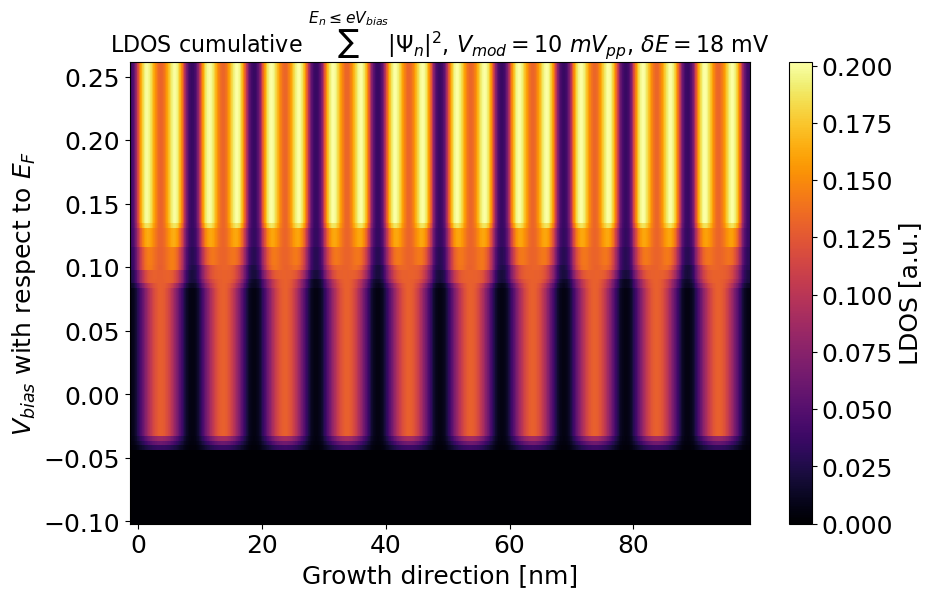

In [6]:
# %matplotlib widget
eVbias = np.linspace(-0.1, 0.26, 100)
Vmod = 0.01 #V 
Ebroad = Vmod*1.8
ldos = simoutidk.bands['CB'].calc_ldos(eVbias,deltaE=Ebroad)
# plot_ldos(simoutidk.bands['CB'], ldos, eVbias,title_diff=r'LDOS cumulative $\sum^{E_n <=eV_{bias}} {|\Psi_n|}^2$')
ldos_ax = plot_ldos(simoutidk.bands['CB'], ldos, eVbias,title_diff=rf'LDOS cumulative $\sum^{{E_n \leq eV_{{bias}}}} {{|\Psi_n|}}^2$, $V_{{mod}}={Vmod*1000:.0f}$ $mV_{{pp}}$, $\delta E={Ebroad*1000:.0f}$ mV',show=False,fontsizetitle=16)
ldos_ax.set_ylabel('$V_{bias}$ with respect to $E_{F}$')


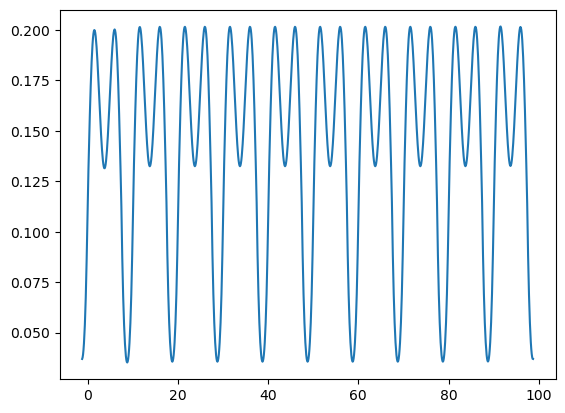

In [7]:
eVbias
summed_probabdist = np.zeros_like(simoutidk.bands['CB'].subbands[0].probab_dist)
for subbands in simoutidk.bands['CB'].subbands:
    summed_probabdist += subbands.probab_dist

plt.plot(simoutidk.bands['CB'].x, summed_probabdist)

In [8]:
simoutidk.bands['CB'].subbands

[<Eigenstate #index=1, energy=-0.024897124677 eV>,
 <Eigenstate #index=2, energy=-0.023989342456 eV>,
 <Eigenstate #index=3, energy=-0.02389046704 eV>,
 <Eigenstate #index=4, energy=-0.021386907689 eV>,
 <Eigenstate #index=5, energy=-0.021321149206 eV>,
 <Eigenstate #index=6, energy=-0.017897526252 eV>,
 <Eigenstate #index=7, energy=-0.017774072499 eV>,
 <Eigenstate #index=8, energy=-0.014764390529 eV>,
 <Eigenstate #index=9, energy=-0.014567218392 eV>,
 <Eigenstate #index=10, energy=-0.013301263322 eV>,
 <Eigenstate #index=11, energy=0.10306155847 eV>,
 <Eigenstate #index=12, energy=0.106907206593 eV>,
 <Eigenstate #index=13, energy=0.107403471922 eV>,
 <Eigenstate #index=14, energy=0.117904994654 eV>,
 <Eigenstate #index=15, energy=0.118528893435 eV>,
 <Eigenstate #index=16, energy=0.132971577849 eV>,
 <Eigenstate #index=17, energy=0.133566756672 eV>,
 <Eigenstate #index=18, energy=0.1472983082 eV>,
 <Eigenstate #index=19, energy=0.147680571866 eV>,
 <Eigenstate #index=20, energy=0.1